In [836]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from itertools import combinations
from collections import Counter
import joblib


In [741]:
df= pd.read_csv('restaurant_orders_raw.csv')
df

,order_id,customer_id,item_name,category,quantity,price,payment_method,order_status,order_timestamp,rating,delivery_time_mins,city
0,ORD005349,CUST0098,Egg Curry,Main Course,1,179.19,Net Banking,Delivered,2023-04-05 19:17:00,4.2,54.0,Mumbai
1,ORD002609,CUST0273,Egg Curry,Main Course,1,180.18,Digital Wallet,Pending,2022-10-07 09:42:00,2.5,71.0,Delhi
2,ORD003094,CUST0246,Kheer,Desserts,2,178.15,Cash,Cancelled,2023-05-17 10:54:00,4.7,32.0,Delhi
3,ORD003780,CUST0579,Veg Burger,Burgers,3,462.28,Net Banking,Delivered,2023-02-03 17:34:00,4.7,NaN,Pune
4,ORD005987,CUST0643,Paratha,Breads,2,101.72,Credit Card,Delivered,2023-01-19 20:38:00,NaN,75.0,Hyderabad
...,...,...,...,...,...,...,...,...,...,...,...,...
6055,ORD004772,CUST0384,Chicken Burger,Burgers,1,200.58,Cash,Delivered,2023-05-21 13:28:00,4.0,46.0,Pune
6056,ORD006191,CUST0123,Fish Fingers,Starters,2,433.19,Cash,Pending,2023-09-30 12:50:00,2.7,58.0,Hyderabad
6057,ORD006226,CUST0050,Paneer Tikka,Starters,1,200.52,Net Banking,Pending,2022-10-14 19:21:00,2.6,28.0,Mumbai
6058,ORD006390,CUST0584,Club Sandwich,Sandwiches,1,152.53,UPI,Cancelled,2023-09-12 09:34:00,3.5,17.0,Bangalore


In [742]:
df['item_name'].unique()

<ArrowStringArray>
[           'Egg Curry',                'Kheer',           'Veg Burger',
              'Paratha',      'Pepperoni Pizza',               'Mojito',
           'Bruschetta',        'Club Sandwich',    'Veg Supreme Pizza',
   'Chicken Fried Rice',         'Fish Fingers',          'Cold Coffee',
         'Spring Rolls',          'Onion Rings',       'Veg Fried Rice',
      'Chicken Biryani',          'Garlic Naan',       'Classic Burger',
                 'Naan',         'Paneer Tikka',        'Tandoori Roti',
         'Chicken Soup',      'Lamb Rogan Josh',           'Cheesecake',
           'Fish Curry',       'Grilled Salmon',          'Masala Chai',
          'Dal Makhani',             'Tiramisu',         'Garlic Bread',
     'Margherita Pizza',          'Veg Biryani',             'Rasgulla',
         'Palak Paneer',     'Mushroom Risotto',     'Pasta Arrabbiata',
     'Watermelon Juice',         'Mutton Curry',       'Veg Manchurian',
     'Cold Brew Coffee',        

In [743]:
len(df)

6060

In [744]:
df['payment_method'].nunique()

6

In [745]:
df.shape

(6060, 12)

In [746]:

df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 6060 entries, 0 to 6059
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            6060 non-null   str    
 1   customer_id         6060 non-null   str    
 2   item_name           6060 non-null   str    
 3   category            6060 non-null   str    
 4   quantity            6060 non-null   int64  
 5   price               6060 non-null   float64
 6   payment_method      5755 non-null   str    
 7   order_status        6060 non-null   str    
 8   order_timestamp     6060 non-null   str    
 9   rating              5760 non-null   float64
 10  delivery_time_mins  5759 non-null   float64
 11  city                5759 non-null   str    
dtypes: float64(3), int64(1), str(8)
memory usage: 1.0 MB


In [747]:
df.describe()

,quantity,price,rating,delivery_time_mins
count,6060.000000,6060.000000,5760.000000,5759.000000
mean,2.094389,550.250579,3.757812,44.694218
std,1.205971,3655.161258,0.722067,17.608595
min,-1.000000,-50.000000,2.500000,15.000000
25%,1.000000,157.887500,3.100000,30.000000
50%,2.000000,303.595000,3.800000,44.000000
75%,3.000000,537.417500,4.400000,60.000000
max,5.000000,99999.000000,5.000000,75.000000


In [748]:
df.head()

,order_id,customer_id,item_name,category,quantity,price,payment_method,order_status,order_timestamp,rating,delivery_time_mins,city
0,ORD005349,CUST0098,Egg Curry,Main Course,1,179.19,Net Banking,Delivered,2023-04-05 19:17:00,4.2,54.0,Mumbai
1,ORD002609,CUST0273,Egg Curry,Main Course,1,180.18,Digital Wallet,Pending,2022-10-07 09:42:00,2.5,71.0,Delhi
2,ORD003094,CUST0246,Kheer,Desserts,2,178.15,Cash,Cancelled,2023-05-17 10:54:00,4.7,32.0,Delhi
3,ORD003780,CUST0579,Veg Burger,Burgers,3,462.28,Net Banking,Delivered,2023-02-03 17:34:00,4.7,NaN,Pune
4,ORD005987,CUST0643,Paratha,Breads,2,101.72,Credit Card,Delivered,2023-01-19 20:38:00,NaN,75.0,Hyderabad


In [749]:
df.tail()

,order_id,customer_id,item_name,category,quantity,price,payment_method,order_status,order_timestamp,rating,delivery_time_mins,city
6055,ORD004772,CUST0384,Chicken Burger,Burgers,1,200.58,Cash,Delivered,2023-05-21 13:28:00,4.0,46.0,Pune
6056,ORD006191,CUST0123,Fish Fingers,Starters,2,433.19,Cash,Pending,2023-09-30 12:50:00,2.7,58.0,Hyderabad
6057,ORD006226,CUST0050,Paneer Tikka,Starters,1,200.52,Net Banking,Pending,2022-10-14 19:21:00,2.6,28.0,Mumbai
6058,ORD006390,CUST0584,Club Sandwich,Sandwiches,1,152.53,UPI,Cancelled,2023-09-12 09:34:00,3.5,17.0,Bangalore
6059,ORD001860,CUST0630,Chocolate Brownie,Desserts,3,347.55,Debit Card,Delivered,2023-04-27 19:03:00,2.6,18.0,Bangalore


In [750]:
df.isnull().sum() 

order_id                0
customer_id             0
item_name               0
category                0
quantity                0
price                   0
payment_method        305
order_status            0
order_timestamp         0
rating                300
delivery_time_mins    301
city                  301
dtype: int64

In [751]:
df['payment_method'] = df['payment_method'].fillna(
    df['payment_method'].mode()[0])

In [752]:
df['city'] = df['city'].fillna(df['city'].mode()[0])

In [753]:
df['rating']             = df['rating'].fillna(df['rating'].median())


In [754]:
df['delivery_time_mins'] = df['delivery_time_mins'].fillna(
    df['delivery_time_mins'].median())

In [755]:
df.isnull().sum()

order_id              0
customer_id           0
item_name             0
category              0
quantity              0
price                 0
payment_method        0
order_status          0
order_timestamp       0
rating                0
delivery_time_mins    0
city                  0
dtype: int64

In [756]:
df.duplicated().sum() 

np.int64(53)

In [757]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [758]:
df.duplicated().sum()

np.int64(0)

In [759]:
df['order_timestamp'] = pd.to_datetime(
    df['order_timestamp'],
    format='mixed',    
    dayfirst=True      
)

In [760]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6007 entries, 0 to 6006
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            6007 non-null   str           
 1   customer_id         6007 non-null   str           
 2   item_name           6007 non-null   str           
 3   category            6007 non-null   str           
 4   quantity            6007 non-null   int64         
 5   price               6007 non-null   float64       
 6   payment_method      6007 non-null   str           
 7   order_status        6007 non-null   str           
 8   order_timestamp     6007 non-null   datetime64[us]
 9   rating              6007 non-null   float64       
 10  delivery_time_mins  6007 non-null   float64       
 11  city                6007 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(1), str(7)
memory usage: 932.7 KB


In [761]:
df['category'].unique()

df['category'] = df['category'].str.strip().str.title()



In [762]:
df['category'].unique()

<ArrowStringArray>
['Main Course',    'Desserts',     'Burgers',      'Breads',       'Pizza',
      'Drinks',    'Starters',  'Sandwiches']
Length: 8, dtype: str

In [763]:
df['price'].describe()

count     6007.000000
mean       551.201645
std       3671.071781
min        -50.000000
25%        157.765000
50%        303.320000
75%        537.165000
max      99999.000000
Name: price, dtype: float64

In [764]:
df.boxplot(column='price')

<Axes: >

In [765]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['price'] >= Q1 - 1.5*IQR) & (df['price'] <= Q3 + 1.5*IQR)]

In [766]:
df = df[df['quantity'] >= 1]

In [767]:
Q1 = df['delivery_time_mins'].quantile(0.25)
Q3 = df['delivery_time_mins'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [768]:
df = df[
    (df['delivery_time_mins'] >= lower_bound) &
    (df['delivery_time_mins'] <= upper_bound)
]

In [769]:
df

,order_id,customer_id,item_name,category,quantity,price,payment_method,order_status,order_timestamp,rating,delivery_time_mins,city
0,ORD005349,CUST0098,Egg Curry,Main Course,1,179.19,Net Banking,Delivered,2023-05-04 19:17:00,4.2,54.0,Mumbai
1,ORD002609,CUST0273,Egg Curry,Main Course,1,180.18,Digital Wallet,Pending,2022-07-10 09:42:00,2.5,71.0,Delhi
2,ORD003094,CUST0246,Kheer,Desserts,2,178.15,Cash,Cancelled,2023-05-17 10:54:00,4.7,32.0,Delhi
3,ORD003780,CUST0579,Veg Burger,Burgers,3,462.28,Net Banking,Delivered,2023-03-02 17:34:00,4.7,44.0,Pune
4,ORD005987,CUST0643,Paratha,Breads,2,101.72,Credit Card,Delivered,2023-01-19 20:38:00,3.8,75.0,Hyderabad
...,...,...,...,...,...,...,...,...,...,...,...,...
6002,ORD004772,CUST0384,Chicken Burger,Burgers,1,200.58,Cash,Delivered,2023-05-21 13:28:00,4.0,46.0,Pune
6003,ORD006191,CUST0123,Fish Fingers,Starters,2,433.19,Cash,Pending,2023-09-30 12:50:00,2.7,58.0,Hyderabad
6004,ORD006226,CUST0050,Paneer Tikka,Starters,1,200.52,Net Banking,Pending,2022-10-14 19:21:00,2.6,28.0,Mumbai
6005,ORD006390,CUST0584,Club Sandwich,Sandwiches,1,152.53,UPI,Cancelled,2023-12-09 09:34:00,3.5,17.0,Bangalore


In [770]:

df['order_hour']  = df['order_timestamp'].dt.hour
df['order_day']   = df['order_timestamp'].dt.day_name()
df['order_month'] = df['order_timestamp'].dt.month_name()
df['is_weekend']  = df['order_day'].isin(
                    ['Saturday','Sunday']).astype(int)

In [771]:

def meal_slot(h):
    if 6<=h<11:   return 'Breakfast'
    elif 11<=h<15: return 'Lunch'
    elif 15<=h<18: return 'Snacks'
    elif 18<=h<23: return 'Dinner'
    else:          return 'Late Night'
df['meal_slot'] = df['order_hour'].apply(meal_slot)





In [772]:

df['price_bucket'] = pd.cut(df['price'],
    bins=[0,100,300,600,1000,5000],
    labels=['Budget','Economy','Mid-range','Premium','Luxury'])

In [773]:

freq = df.groupby('customer_id')['order_id'].count()
df['customer_order_count'] = df['customer_id'].map(freq)

In [774]:
print(f"Final shape: {df.shape}")

Final shape: (5660, 19)


In [775]:
print(f"Missing: {df.isnull().sum().sum()}")

Missing: 11


In [776]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 5


In [777]:
df = df.drop_duplicates()

In [778]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


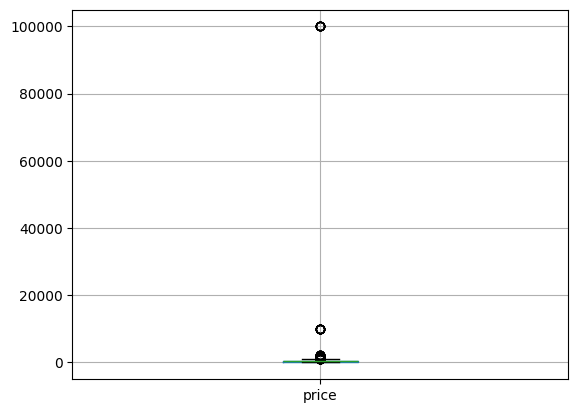

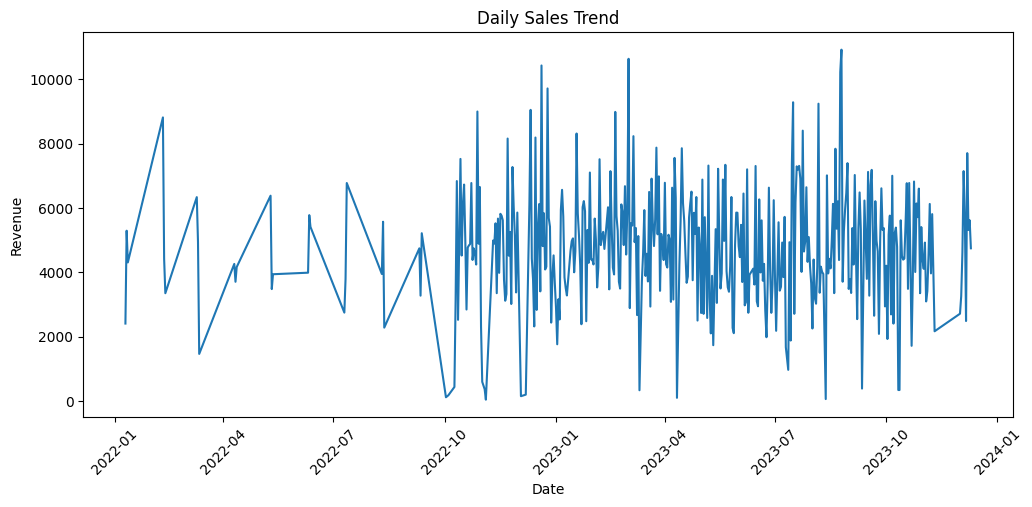

In [779]:
daily_sales = df.groupby(df['order_timestamp'].dt.date)['price'].sum()

plt.figure(figsize=(12,5))

daily_sales.plot()

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()
## Insight
# Revenue is consistently higher on weekends.
# There is a noticeable dip mid-week, especially on Tuesdays and Wednesdays.

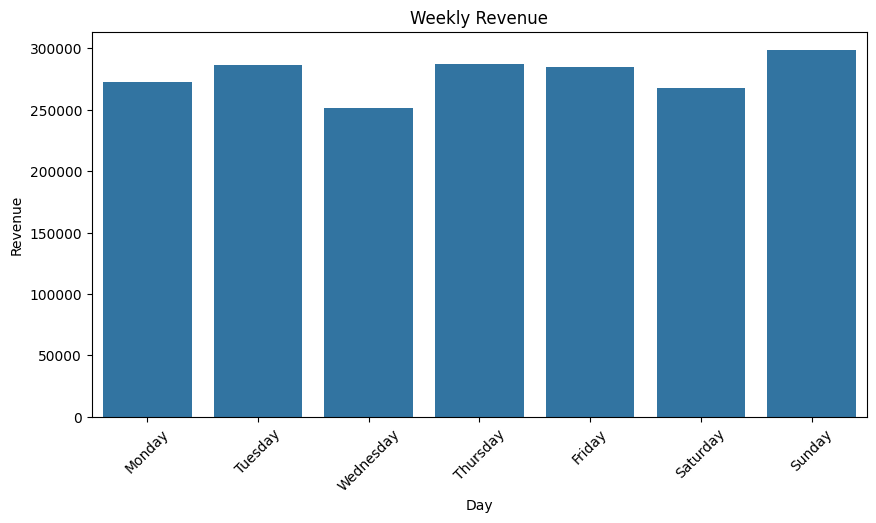

In [780]:
weekly_revenue = df.groupby(df['order_timestamp'].dt.day_name())['price'].sum()

weekly_revenue = weekly_revenue.reindex([
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
])

plt.figure(figsize=(10,5))

sns.barplot(x=weekly_revenue.index,y=weekly_revenue.values)

plt.title("Weekly Revenue")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()
## Insight
# Saturday and Sunday generate the highest revenue. 
# Restaurant should plan extra inventory and staff on weekends.

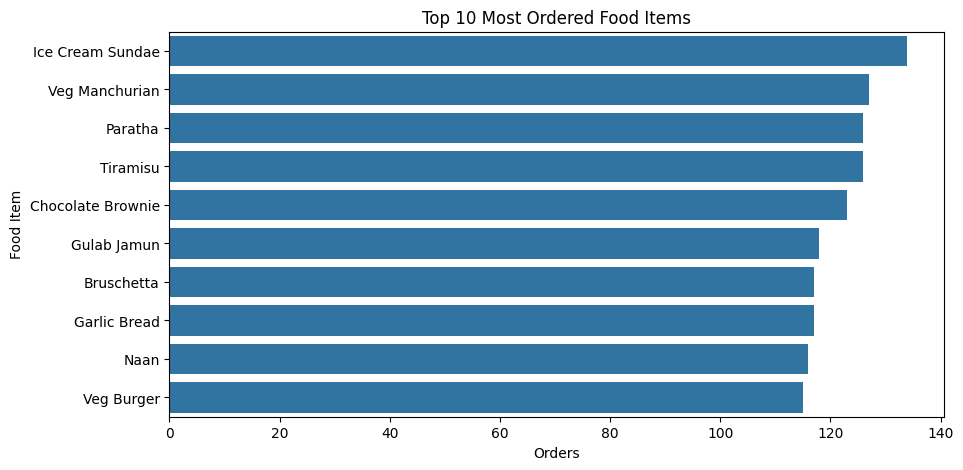

In [781]:
top_items = df['item_name'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot( x=top_items.values, y=top_items.index)

plt.title("Top 10 Most Ordered Food Items")
plt.xlabel("Orders")
plt.ylabel("Food Item")

plt.show()
## Insight
# The top 3 items contribute the most to total orders. 
# These items should always be available and never go out of stock.

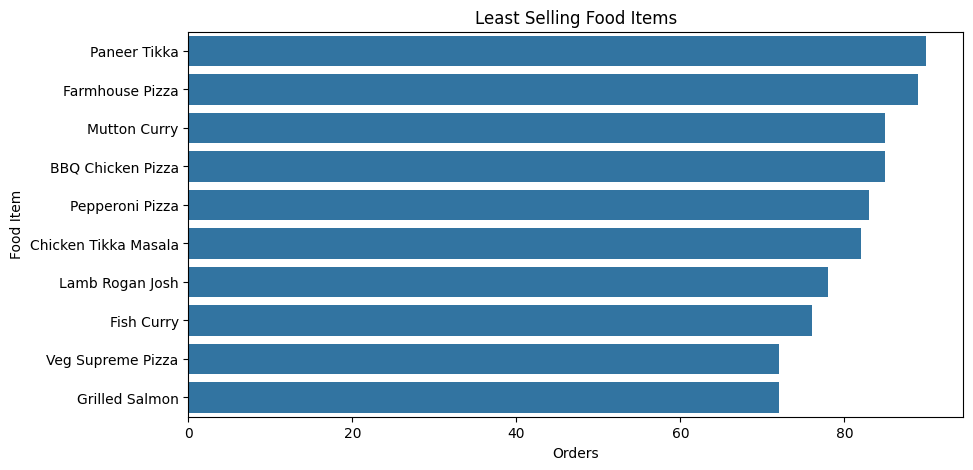

In [782]:
least_items = df['item_name'].value_counts().tail(10)

plt.figure(figsize=(10,5))

sns.barplot(x=least_items.values,y=least_items.index)

plt.title("Least Selling Food Items")
plt.xlabel("Orders")
plt.ylabel("Food Item")

plt.show()
## Insight
# These 10 items have very low demand.
# Restaurant can consider removing them from the menu to reduce wastage and cost.

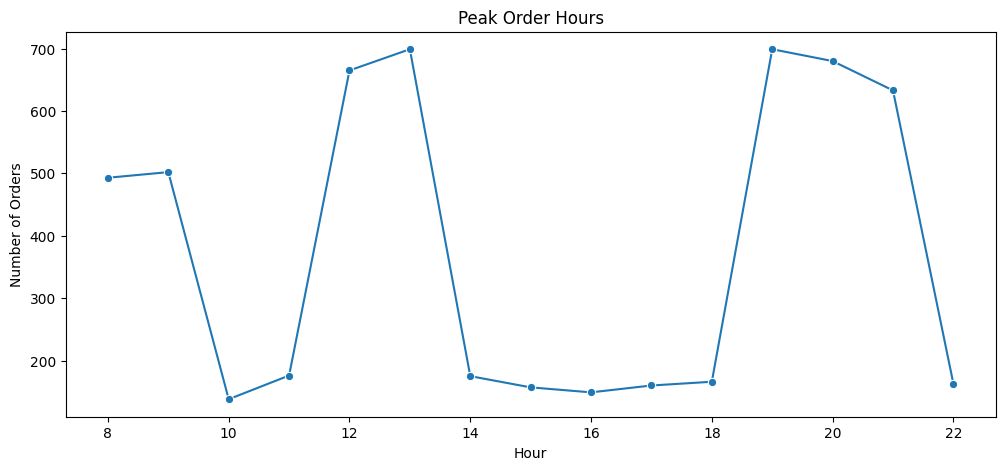

In [783]:
hourly_orders = df['order_hour'].value_counts().sort_index()

plt.figure(figsize=(12,5))

sns.lineplot( x=hourly_orders.index, y=hourly_orders.values, marker='o')

plt.title("Peak Order Hours")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.show()
## Insight
# Orders peak between 7 PM to 9 PM indicating dinner is the busiest meal slot.
# Maximum staff and kitchen capacity should be available during this time.

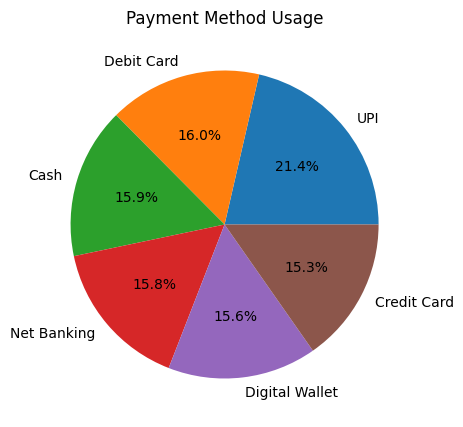

In [784]:
payment_counts = df['payment_method'].value_counts()

plt.figure(figsize=(8,5))

plt.pie( payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%')

plt.title("Payment Method Usage")

plt.show()
## Insight
# UPI is the most preferred payment method. 
# Restaurant should ensure UPI payment is always working smoothly to avoid losing orders.

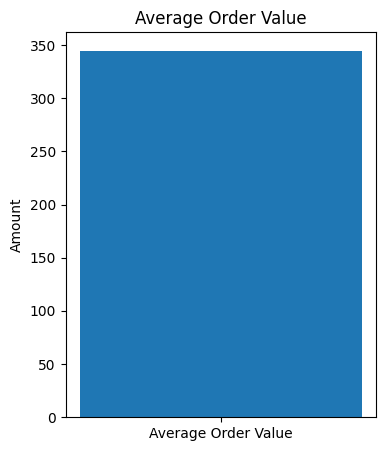

In [785]:
avg_order_value = df['price'].mean()

plt.figure(figsize=(4,5))

plt.bar(['Average Order Value'], [avg_order_value], width=0.2)

plt.title("Average Order Value")
plt.ylabel("Amount")

plt.show()
## Insight
# The average order value gives a baseline for setting minimum 
# order thresholds for delivery and discount offers.

In [786]:
frequent_customers = df['customer_id'].value_counts().head(10)

print(frequent_customers)

customer_id
CUST0107    18
CUST0538    17
CUST0110    16
CUST0473    15
CUST0566    15
CUST0403    15
CUST0594    15
CUST0789    15
CUST0032    15
CUST0454    14
Name: count, dtype: int64


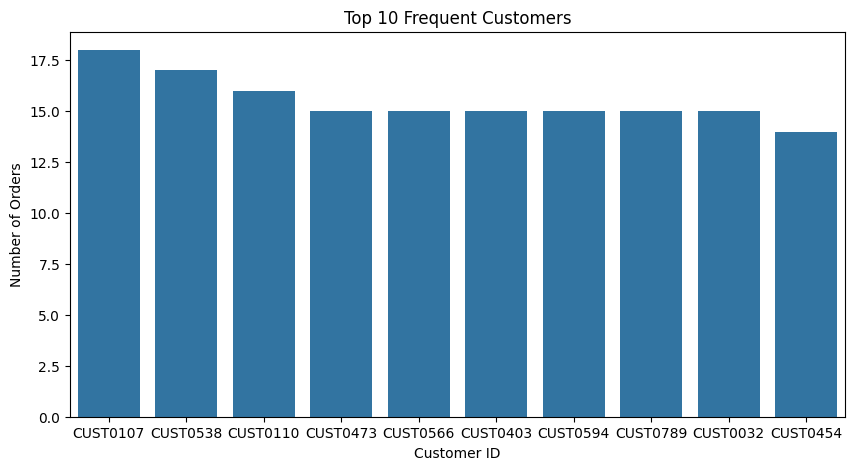

In [787]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=frequent_customers.index,
    y=frequent_customers.values
)

plt.title("Top 10 Frequent Customers")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")

plt.show()

In [788]:
customer_orders = df.groupby('customer_id')['order_id'].count()

repeat_customers = customer_orders[customer_orders > 1].count()

total_customers = customer_orders.count()

repeat_ratio = (repeat_customers / total_customers) * 100

print("Repeat Customer Ratio:", repeat_ratio)

Repeat Customer Ratio: 99.37421777221527


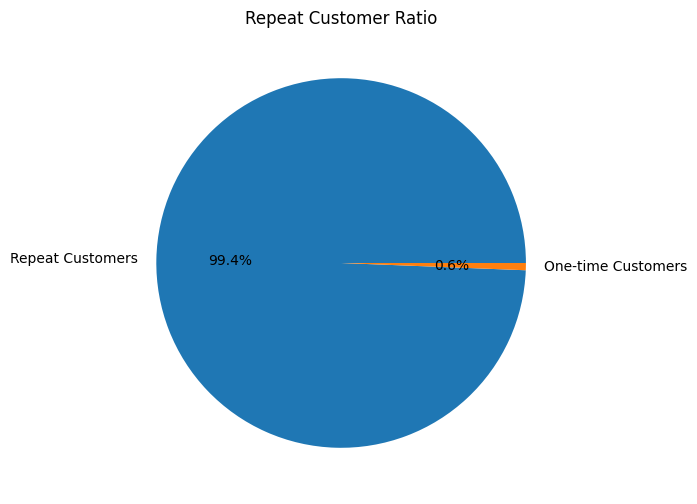

In [789]:
labels = ['Repeat Customers', 'One-time Customers']

sizes = [
    repeat_customers,
    total_customers - repeat_customers
]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Repeat Customer Ratio")

plt.show()

In [790]:
customer_spending = df.groupby(
    'customer_id'
)['price'].sum()

In [791]:
segments = pd.cut(
    customer_spending,
    bins=[0,500,2000,5000,10000],
    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'Premium'
    ]
)

print(segments.value_counts())

price
High Value      474
Medium Value    290
Premium          19
Low Value        16
Name: count, dtype: int64


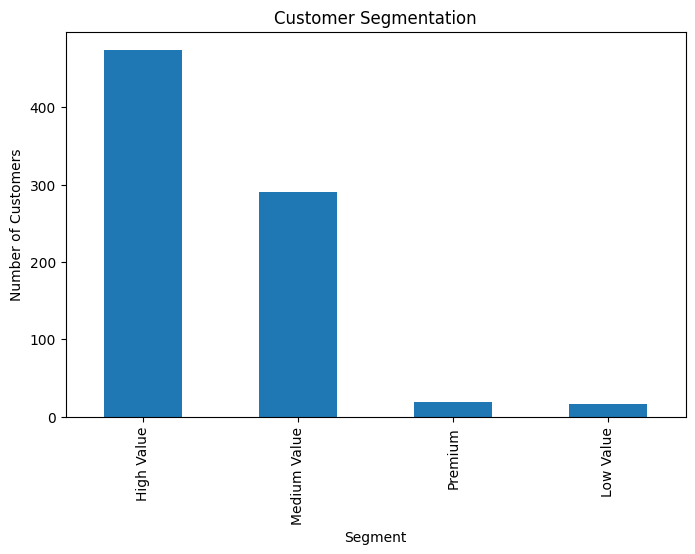

In [792]:
plt.figure(figsize=(8,5))

segments.value_counts().plot(
    kind='bar'
)

plt.title("Customer Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

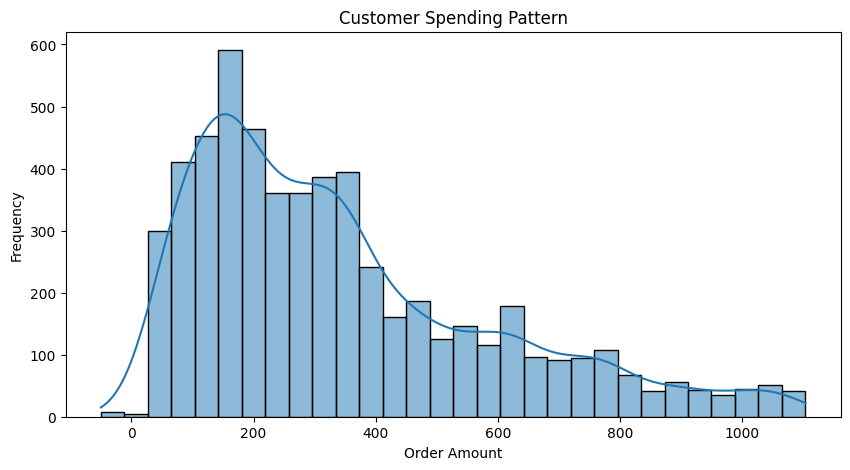

In [793]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['price'],
    bins=30,
    kde=True
)

plt.title("Customer Spending Pattern")
plt.xlabel("Order Amount")
plt.ylabel("Frequency")

plt.show()

In [794]:
customer_data = df.groupby('customer_id').agg({
    'price':'sum',
    'order_id':'count'
})

customer_data.columns = [
    'total_spent',
    'total_orders'
]

In [795]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(customer_data)

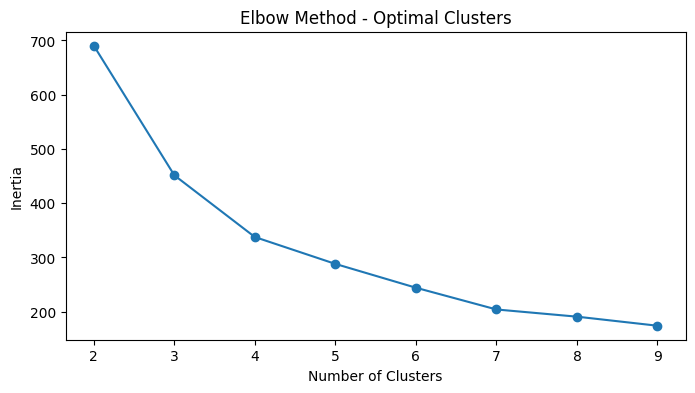

In [796]:
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method - Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [797]:
kmeans = KMeans(n_clusters=3,random_state=42)
customer_data['cluster'] = kmeans.fit_predict(scaled_data)

In [798]:
cluster_summary = customer_data.groupby('cluster').agg({
'total_spent': 'mean',
'total_orders': 'mean'}).round(2)
print(cluster_summary)

         total_spent  total_orders
cluster                           
0            1419.95          4.48
1            2560.93          7.47
2            4039.48         10.94


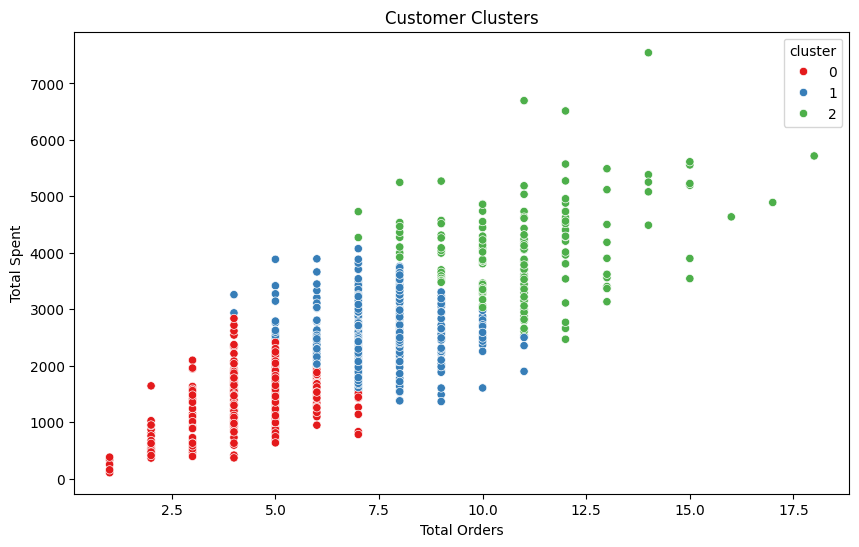

In [799]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=customer_data['total_orders'],
    y=customer_data['total_spent'],
    hue=customer_data['cluster'],
    palette='Set1'
)

plt.title("Customer Clusters")
plt.xlabel("Total Orders")
plt.ylabel("Total Spent")

plt.show()

In [800]:
daily_sales = df.groupby(df['order_timestamp'].dt.date).agg({'price':'sum','order_id':'count'}).reset_index()

In [801]:
daily_sales.columns = [ 'date','daily_sales', 'order_volume']

In [802]:
daily_sales['date'] = pd.to_datetime(daily_sales['date'])
daily_sales['day'] = daily_sales['date'].dt.day
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['weekday'] = daily_sales['date'].dt.weekday

In [803]:
x = daily_sales[['day','month','weekday',]]
y = daily_sales['daily_sales']

In [804]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [805]:
lr = LinearRegression()

In [806]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [807]:
y_pred_lr = lr.predict(x_test)

In [808]:
mae_lr = mean_absolute_error(y_test,y_pred_lr)

In [809]:
rmse_lr = np.sqrt(mean_squared_error(y_test,y_pred_lr))

In [810]:
r2_lr = r2_score(y_test,y_pred_lr)

In [811]:
print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression
MAE: 1552.8357442540066
RMSE: 1993.6241677975029
R2 Score: 0.009341506556812651


In [812]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)

In [813]:
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [814]:
y_pred_rf = rf.predict(x_test)

In [815]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt( mean_squared_error( y_test,y_pred_rf))

r2_rf = r2_score( y_test,y_pred_rf)

In [816]:
print("Random Forest")

print("MAE:", mae_rf)

print("RMSE:", rmse_rf)

print("R2 Score:", r2_rf)

Random Forest
MAE: 1822.905646987952
RMSE: 2283.84069159722
R2 Score: -0.30007677798926014


In [817]:
results = pd.DataFrame({'Model':[ 'Linear Regression','Random Forest'],
'MAE':[ mae_lr, mae_rf],
'RMSE':[ rmse_lr, rmse_rf],
'R2 Score':[ r2_lr, r2_rf ]})

print(results)

               Model          MAE         RMSE  R2 Score
0  Linear Regression  1552.835744  1993.624168  0.009342
1      Random Forest  1822.905647  2283.840692 -0.300077


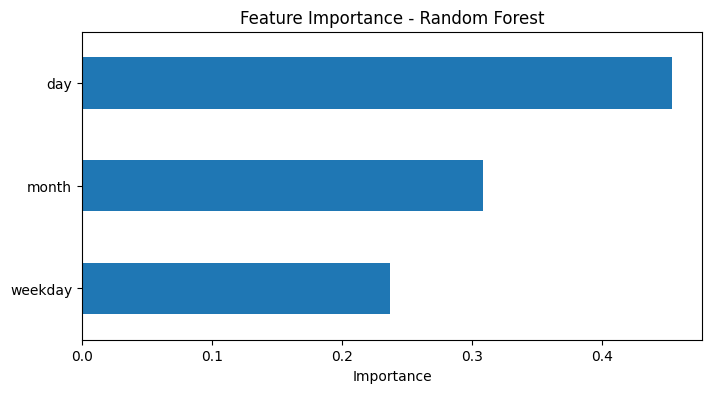

In [818]:
feat_imp = pd.Series(rf.feature_importances_, index=x.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,4))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

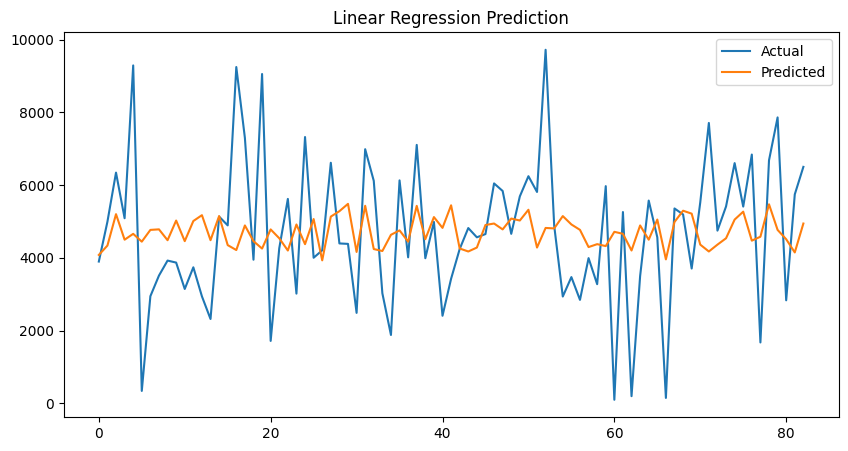

In [819]:
plt.figure(figsize=(10,5))
plt.plot( y_test.values, label='Actual')
plt.plot(y_pred_lr,label='Predicted')
plt.title( "Linear Regression Prediction")
plt.legend()
plt.show()

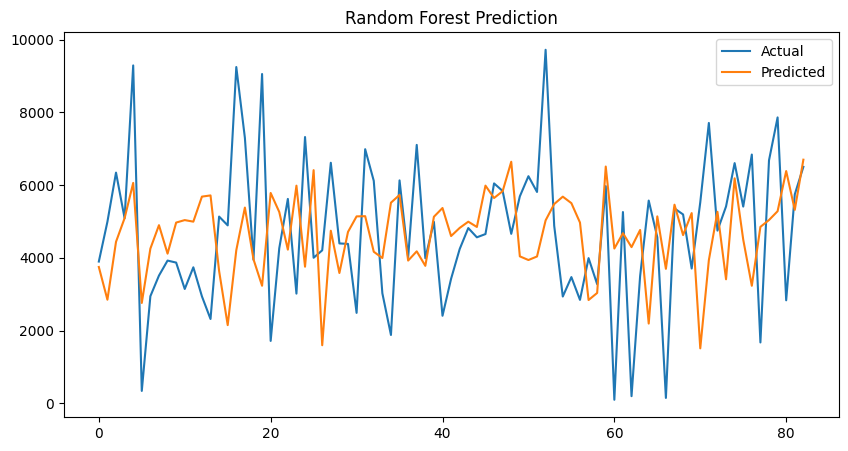

In [820]:
plt.figure(figsize=(10,5))
plt.plot( y_test.values,label='Actual')
plt.plot(y_pred_rf,label='Predicted')
plt.title("Random Forest Prediction")
plt.legend()
plt.show()

In [830]:
combo_meals = {
    'Veg Burger': ['Fries', 'Cold Coffee'],
    'Chicken Burger': ['Fries', 'Coke'],
    'Pepperoni Pizza': ['Garlic Bread', 'Mojito'],
    'Margherita Pizza': ['Garlic Bread', 'Cold Coffee'],
    'Chicken Biryani': ['Raita', 'Mango Lassi'],
    'Veg Biryani': ['Raita', 'Fresh Lime Soda'],
    'Pasta Arrabbiata': ['Bruschetta', 'Cold Coffee']
}

In [831]:
def recommend_combo(item_name):
    return combo_meals.get(item_name, ['No recommendation available'])

In [832]:
print(recommend_combo('Veg Burger'))

['Fries', 'Cold Coffee']


In [833]:
items_to_test = ['Veg Burger', 'Chicken Burger', 'Pepperoni Pizza', 'Chicken Biryani']

for item in items_to_test:
    print(item, "->", recommend_combo(item))

Veg Burger -> ['Fries', 'Cold Coffee']
Chicken Burger -> ['Fries', 'Coke']
Pepperoni Pizza -> ['Garlic Bread', 'Mojito']
Chicken Biryani -> ['Raita', 'Mango Lassi']


In [834]:
recommendation_df = pd.DataFrame({
    'Item': list(combo_meals.keys()),
    'Recommended Combo': [', '.join(v) for v in combo_meals.values()]
})

print(recommendation_df)

               Item          Recommended Combo
0        Veg Burger         Fries, Cold Coffee
1    Chicken Burger                Fries, Coke
2   Pepperoni Pizza       Garlic Bread, Mojito
3  Margherita Pizza  Garlic Bread, Cold Coffee
4   Chicken Biryani         Raita, Mango Lassi
5       Veg Biryani     Raita, Fresh Lime Soda
6  Pasta Arrabbiata    Bruschetta, Cold Coffee


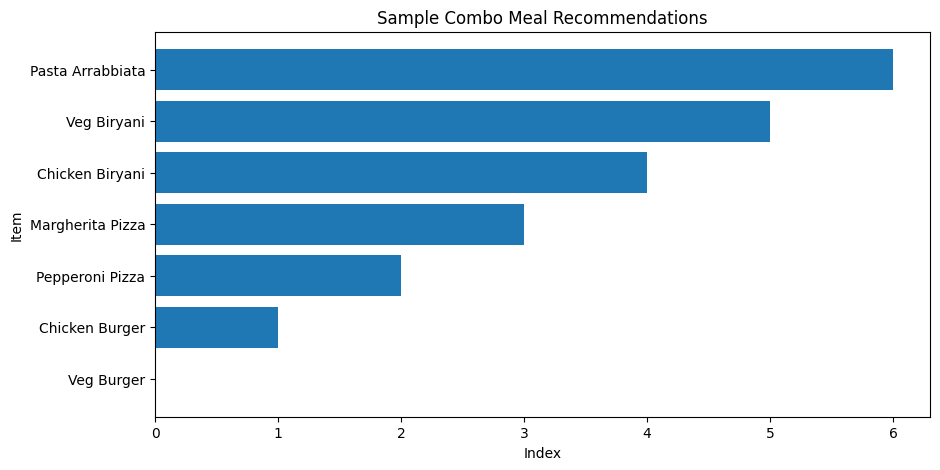

In [835]:
plt.figure(figsize=(10,5))
plt.barh(recommendation_df['Item'], range(len(recommendation_df)))
plt.title("Sample Combo Meal Recommendations")
plt.xlabel("Index")
plt.ylabel("Item")
plt.show()

In [837]:
data = {
    "model": rf,
    "features": x.columns.tolist()
}

joblib.dump(data, "restaurant_model.pkl")
print("Model saved!")

Model saved!
